# Module 05: Scikit-Learn for Machine Learning
## Notebook 05: Validation Strategies, Hyperparameter Tuning, and Model Deployment

A machine learning model is only as reliable as its validation framework. Default hyperparameters rarely deliver optimal performance; systematic tuning and leak-free cross-validation are essential to producing generalizable models.

---

### Learning Objectives
By the end of this notebook, you will be able to:
1. Implement **Stratified K-Fold Cross-Validation** to reliably evaluate model stability.
2. Execute exhaustive parameter exploration using **`GridSearchCV`**.
3. Accelerate hyperparameter search over large spaces using **`RandomizedSearchCV`**.
4. Diagnose Underfitting (High Bias) vs. Overfitting (High Variance) using **`learning_curve()`**.
5. Save, serialize, and reload trained production pipelines using **`joblib`**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

print("Loaded Scikit-Learn Validation and Tuning Modules!")

Loaded Scikit-Learn Validation and Tuning Modules!


### 1. Stratified K-Fold Cross-Validation

Evaluating a model on a single train-test split can yield misleading estimates due to lucky or unlucky sample partitioning.
In **$K$-Fold Cross-Validation**:
- The training data is divided into $K$ equal subsets (folds).
- The model is trained on $K - 1$ folds and evaluated on the remaining fold.
- This process repeats $K$ times so every sample is used for validation exactly once.

In [2]:
# Load real-world medical diagnostic benchmark (Breast Cancer dataset)
cancer_data = load_breast_cancer()
X, y = cancer_data.data, cancer_data.target

# Pipeline with scaler and Random Forest
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42))
])

# 5-Fold Stratified Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')

print(f"5-Fold ROC-AUC Scores: {np.round(cv_scores, 4)}")
print(f"Mean CV ROC-AUC:      {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

5-Fold ROC-AUC Scores: [0.9984 0.9785 0.9788 0.9945 0.9925]
Mean CV ROC-AUC:      0.9885 (+/- 0.0083)


---
### 2. Systematic Hyperparameter Tuning: `GridSearchCV`

`GridSearchCV` tests every combination in a discrete parameter grid inside an embedded cross-validation loop.

In [3]:
# Define hyperparameter candidate grid
param_grid = {
    'rf__n_estimators': [50, 100],
    'rf__max_depth': [3, 5, 8],
    'rf__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    return_train_score=False
)

grid_search.fit(X, y)

print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best CV ROC-AUC Score: {grid_search.best_score_:.4f}")

Best Hyperparameters: {'rf__max_depth': 5, 'rf__min_samples_split': 2, 'rf__n_estimators': 100}
Best CV ROC-AUC Score: 0.9903


---
### 3. Diagnosing Bias vs. Variance with Learning Curves

- **High Bias (Underfitting)**: Both training and validation scores are low and flat. The model lacks capacity to learn patterns.
- **High Variance (Overfitting)**: Training score is high, but validation score lags far behind (large generalization gap). Adding more training data usually helps!

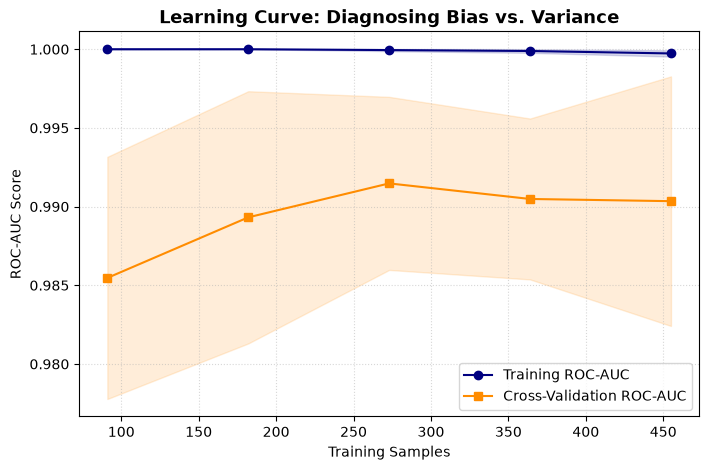

In [4]:
train_sizes, train_scores, test_scores = learning_curve(
    grid_search.best_estimator_,
    X, y,
    cv=cv,
    scoring='roc_auc',
    train_sizes=np.linspace(0.2, 1.0, 5),
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(train_sizes, train_mean, 'o-', color='navy', label='Training ROC-AUC')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='navy')

ax.plot(train_sizes, test_mean, 's-', color='darkorange', label='Cross-Validation ROC-AUC')
ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color='darkorange')

ax.set_title("Learning Curve: Diagnosing Bias vs. Variance", fontsize=13, fontweight='bold')
ax.set_xlabel("Training Samples")
ax.set_ylabel("ROC-AUC Score")
ax.legend(loc='lower right')
ax.grid(True, linestyle=':', alpha=0.5)

plt.show()

---
### 4. Model Persistence and Serialization: `joblib`

Once you have tuned an optimal pipeline, you must serialize it to disk so production inference servers can load it without retraining.

In [5]:
model_path = "best_cancer_classifier_pipeline.joblib"

# 1. Save the best fitted pipeline
joblib.dump(grid_search.best_estimator_, model_path)
print(f"Serialized production pipeline to: {model_path}")

# 2. Reload pipeline from disk
loaded_model = joblib.load(model_path)

# Verify inference with reloaded model
sample_input = X[:2]
prediction = loaded_model.predict(sample_input)
probabilities = loaded_model.predict_proba(sample_input)

print(f"Inference verified with loaded pipeline! Predictions: {prediction}")

# Clean up test artifact
if os.path.exists(model_path):
    os.remove(model_path)

Serialized production pipeline to: best_cancer_classifier_pipeline.joblib
Inference verified with loaded pipeline! Predictions: [0 0]


### Curriculum Conclusion & Next Horizons
Congratulations! You have completed the entire 5-Module Machine Learning Foundation Curriculum:
1. **01_numpy**: Contiguous array computing, vectorization, linear systems, eigenvalues, and algorithms from scratch.
2. **02_pandas**: Tabular data manipulation, missingness imputation, aggregations, relational joins, and feature engineering.
3. **03_matplotlib**: Object-Oriented figure design, statistical charts, multi-panel layouts, and diagnostic surfaces.
4. **04_seaborn**: Multivariate relational mapping, confidence bands, masked heatmaps, and systematic 5-step EDA.
5. **05_scikit_learn**: Preprocessing pipelines, regularized regression, classification on imbalanced data, unsupervised clustering/PCA, and hyperparameter tuning.

You are now prepared to build, evaluate, and deploy production-grade machine learning models!